In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
import matplotlib.cm as cm
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from time import perf_counter
import seaborn as sns
from datetime import datetime

In [ ]:
### Some code inspired by https://www.kaggle.com/code/databeru/sign-language-mnist-classifier-acc-99-78

In [21]:
# Script to import data while reducing memory usage, work by Guillaume Martin
# https://www.kaggle.com/code/gemartin/load-data-reduce-memory-usage

def reduce_mem_usage(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df


def import_data(file):
    df = pd.read_csv(file, parse_dates=True, keep_date_col=True)
    df = reduce_mem_usage(df)
    return df

In [22]:
train_df = import_data('sign_mnist_train.csv' )
test_df = import_data('test.csv')

Memory usage of dataframe is 164.43 MB
Memory usage after optimization is: 41.08 MB
Decreased by 75.0%
Memory usage of dataframe is 35.91 MB
Memory usage after optimization is: 8.98 MB
Decreased by 75.0%


In [23]:
image_a_df = test_df.iloc[:, [0] + list(range(1, 785))]
image_b_df = test_df.iloc[:, [0] + list(range(785, test_df.shape[1]))]
columns = train_df.drop('label', axis=1).columns
image_a_df.columns = [image_a_df.columns[0]] + list(columns)
image_b_df.columns = [image_b_df.columns[0]] + list(columns)
test_df = pd.concat([image_a_df, image_b_df], axis=0)

In [24]:
print(f'Number of images in the training set: {train_df.shape[0]}')
print(f'Number of images in the test set: {test_df.shape[0]//2}')

d = int((train_df.shape[1] - 1)**0.5)
print(f'Shape of the images: {d} x {d}')

Number of images in the training set: 27455
Number of images in the test set: 3000
Shape of the images: 28 x 28


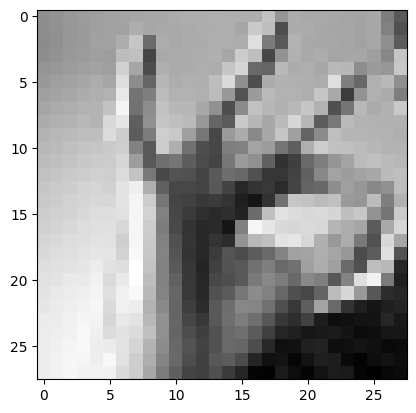

In [28]:
def to_image(array, label = True):
    array = np.array(array)
    start_idx = 1 if label else 0
    return array[start_idx:].reshape(28,28).astype(float)
        
# Display a random image
img_index = np.random.choice(list(range(0,train_df.shape[0])))
img = to_image(train_df.iloc[img_index])
plt.imshow(img, cmap = 'gray')
plt.show()

In [29]:
alphab = 'abcdefghijklmnopqrstuvwxyz'
mapping_letter = {}

for i,l in enumerate(alphab):
    mapping_letter[l] = i
mapping_letter = {v:k for k,v in mapping_letter.items()}

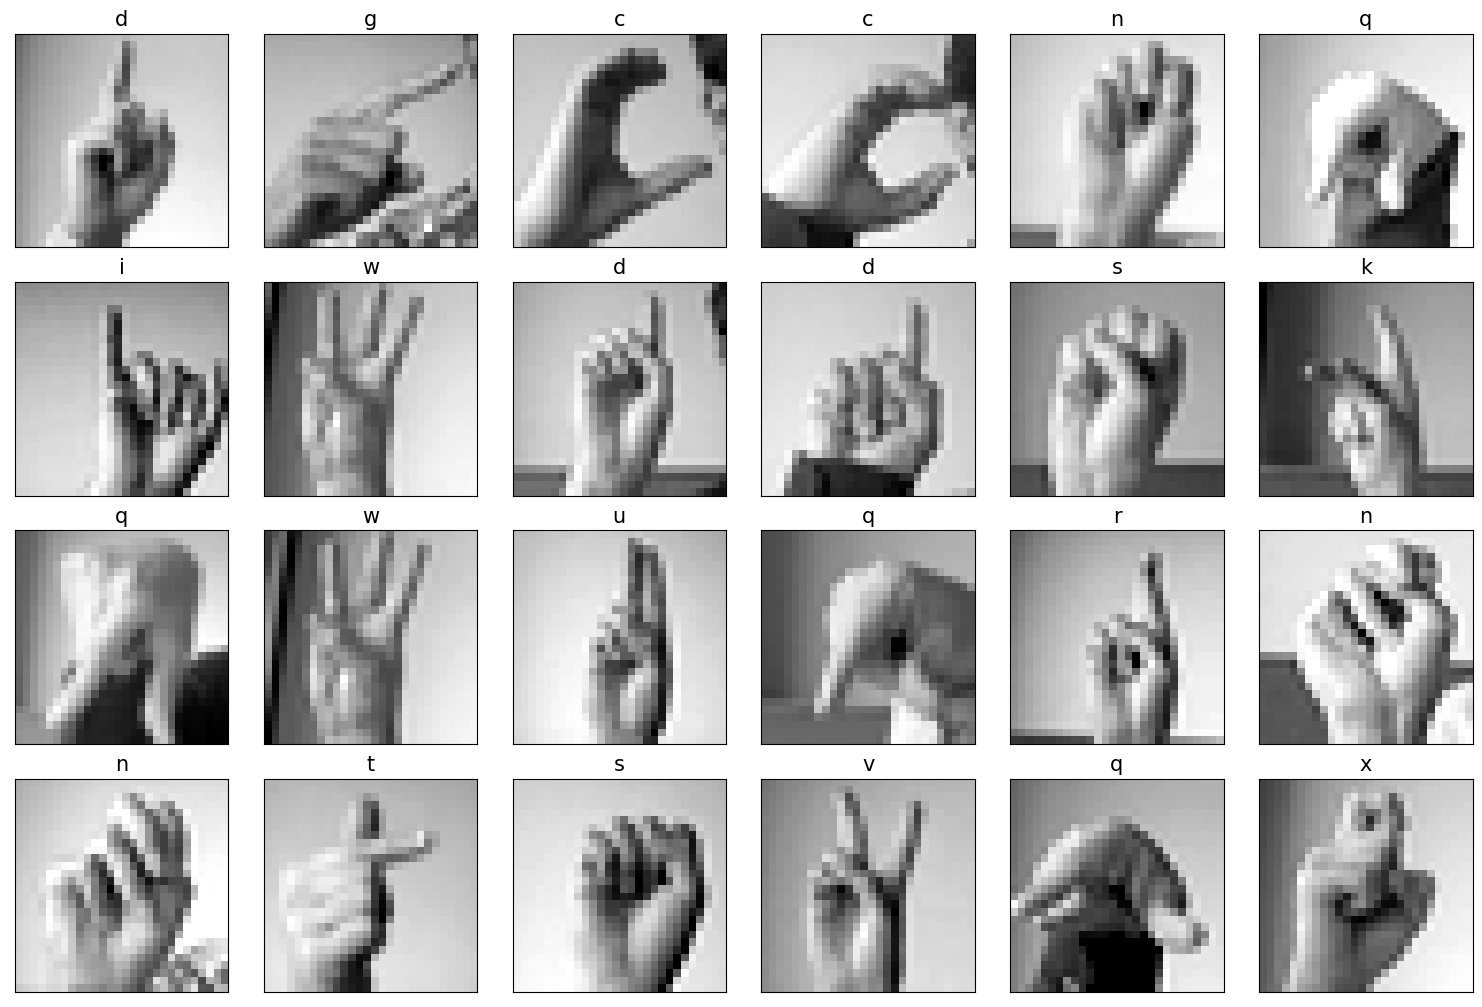

In [31]:
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(15, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    img = to_image(train_df.iloc[i])
    ax.imshow(img, cmap = 'gray')
    title = mapping_letter[train_df.label[i]]
    ax.set_title(title, fontsize = 15)
plt.tight_layout(pad=0.5)
plt.show()

In [32]:
train_df_original = train_df.copy()
val_index = int(train_df.shape[0]*0.1)

train_df = train_df_original.iloc[val_index:]
val_df = train_df_original.iloc[:val_index]

y_train = train_df['label']
y_val = val_df['label']

X_train = train_df.drop('label',axis = 1).values.reshape(train_df.shape[0], 28, 28, 1)
X_val = val_df.drop('label',axis = 1).values.reshape(val_df.shape[0], 28, 28, 1)
X_test = test_df.drop('id', axis=1).values.reshape(test_df.shape[0], 28, 28, 1)

In [33]:
X_train.shape, X_val.shape, X_test.shape

((24710, 28, 28, 1), (2745, 28, 28, 1), (6000, 28, 28, 1))

In [34]:
# Data augmentation
generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255,
                                                            rotation_range=10,
                                                            zoom_range=0.10,
                                                            width_shift_range=0.1,
                                                            height_shift_range=0.1,
                                                            shear_range=0.1,
                                                            horizontal_flip=False,
                                                            fill_mode="nearest")

X_train_flow = generator.flow(X_train, y_train, batch_size=32)
X_val_flow = generator.flow(X_val, y_val, batch_size=32)
# X_test_flow = generator.flow(X_test, y_test)

In [35]:
model = Sequential([Conv2D(filters=32,  kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
                    MaxPool2D(2,2, padding='same'),
                    
                    Conv2D(filters=128,  kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    
                    Conv2D(filters=512, kernel_size=(3,3), activation="relu"),
                    MaxPool2D(2,2, padding='same'),
                    
                    Flatten(),
                    
                    Dense(units=1024, activation="relu"),                 
                    Dense(units=256, activation="relu"),
                    Dropout(0.5),
                    Dense(units=25, activation="softmax")
])

model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=["accuracy"])


model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 11, 11, 128)       36992     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 6, 6, 128)        0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 512)         590336    
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 2, 2, 512)       

In [36]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1,factor=0.5, min_lr=0.00001)

history = model.fit(X_train_flow, 
                    validation_data=X_val_flow, 
                    epochs=1,
                    callbacks=[
                            tf.keras.callbacks.EarlyStopping(
                            monitor='val_loss',
                            patience=5,
                            restore_best_weights=True), 
                        
                            learning_rate_reduction
                    ])

773/773 [==============================] - 65s 83ms/step - loss: 1.6311 - accuracy: 0.4668 - val_loss: 0.4448 - val_accuracy: 0.8397 - lr: 0.0010


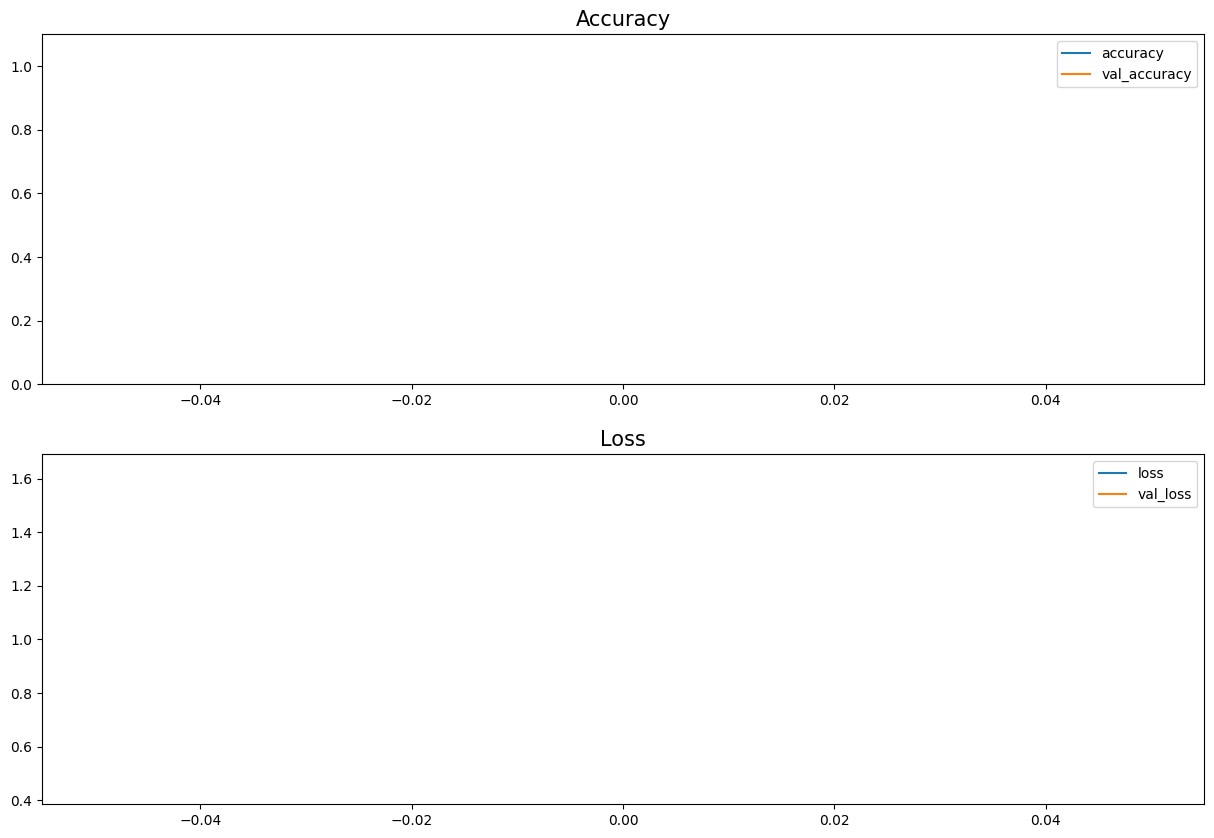

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
ax = axes.flat

pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot(ax=ax[0])
ax[0].set_title("Accuracy", fontsize = 15)
ax[0].set_ylim(0,1.1)

pd.DataFrame(history.history)[['loss','val_loss']].plot(ax=ax[1])
ax[1].set_title("Loss", fontsize = 15)
plt.show()

In [38]:
# Predict the label of the test_images
pred = model.predict(X_test)
pred = np.argmax(pred,axis=1)

188/188 [==============================] - 3s 14ms/step


In [40]:
def convert_to_char(ascii_sum):
    if ascii_sum > 122:
        return chr(ascii_sum - 65)
    return chr(ascii_sum)

def convert_predictions_to_chars(predictions):
    return [str(convert_to_char(65 + pred)) for pred in predictions]

char_predictions = convert_predictions_to_chars(pred)
print(char_predictions)

['G', 'C', 'B', 'M', 'K', 'V', 'T', 'O', 'E', 'Y', 'M', 'C', 'E', 'M', 'A', 'E', 'O', 'U', 'K', 'O', 'F', 'I', 'M', 'T', 'Q', 'M', 'I', 'B', 'M', 'F', 'I', 'I', 'E', 'C', 'C', 'D', 'C', 'V', 'E', 'B', 'B', 'P', 'S', 'U', 'S', 'S', 'I', 'X', 'F', 'K', 'K', 'M', 'D', 'O', 'G', 'E', 'O', 'O', 'A', 'M', 'E', 'S', 'I', 'Q', 'A', 'M', 'T', 'P', 'G', 'X', 'X', 'B', 'Y', 'I', 'C', 'R', 'T', 'A', 'S', 'R', 'S', 'H', 'R', 'M', 'G', 'V', 'F', 'A', 'S', 'M', 'C', 'E', 'Q', 'B', 'I', 'V', 'I', 'C', 'Q', 'C', 'X', 'X', 'E', 'M', 'K', 'I', 'R', 'M', 'F', 'S', 'S', 'C', 'F', 'V', 'D', 'F', 'G', 'R', 'D', 'X', 'V', 'M', 'R', 'S', 'E', 'X', 'R', 'A', 'H', 'V', 'C', 'U', 'K', 'B', 'I', 'Q', 'M', 'S', 'C', 'H', 'U', 'Q', 'H', 'B', 'S', 'B', 'U', 'Y', 'Q', 'K', 'P', 'H', 'V', 'E', 'M', 'X', 'R', 'Q', 'M', 'S', 'B', 'M', 'W', 'E', 'B', 'R', 'X', 'S', 'R', 'X', 'D', 'R', 'H', 'D', 'D', 'E', 'M', 'S', 'F', 'S', 'G', 'X', 'E', 'R', 'V', 'M', 'X', 'L', 'Y', 'B', 'E', 'F', 'Q', 'F', 'G', 'P', 'S', 'S', 'D', 'T',

In [41]:
pred_ascii = [ord(i) for i in char_predictions]

In [42]:
combined_predictions = [pred_ascii[i] + pred_ascii[i + 3000] for i in range(3000)]

In [43]:
def convert_predictions_to_chars2(predictions):
    return [str(convert_to_char(pred)) for pred in predictions]

In [44]:
char_predictions_final = convert_predictions_to_chars2(combined_predictions)
print(char_predictions_final)

['Z', 'Z', 'G', '[', '\\', 'm', '`', 'O', 'Q', 'Y', '^', 'V', 'L', 'M', 'A', 'K', 'g', 'g', 'S', '_', 'R', 'Q', '_', 'j', 'R', 'P', 'I', 'W', 'R', ']', 'O', ']', '\\', 'W', 'D', 'F', 'I', '`', 'M', 'T', 'J', '\\', '[', '[', 'c', 'c', 'L', 'X', 'G', 'O', 'c', 'a', '\\', 'P', 'N', 'L', 'Q', 'R', 'H', 'N', 'F', 'e', '\\', '[', 'G', 'R', 'c', '\\', 'X', 'i', '^', 'B', ']', 'P', 'H', 'X', 'a', 'M', 'i', 'Z', 'V', 'X', 'b', 'U', 'N', 'W', 'V', 'O', 'e', '_', 'H', 'Y', 'T', 'G', '`', 'V', 'Z', 'Z', 'W', 'E', ']', '\\', 'E', '^', '^', '[', 'Z', 'Q', 'W', 'd', 'V', 'T', 'H', 'f', 'G', 'J', 'I', 'd', 'U', 'm', 'a', 'O', 'Z', 'i', 'K', 'o', 'V', 'C', 'Z', ']', 'R', '`', 'U', 'M', '`', 'U', 'X', 'W', '[', 'T', 'Y', 'f', 'Z', 'Q', 'Z', 'D', 'm', 'k', 'R', '\\', 'T', 'W', 'm', 'O', ']', 'o', 'g', '\\', 'Q', '[', 'N', '_', ']', 'M', 'F', 'T', 'e', 'T', 'Z', 'Y', '[', 'V', 'K', 'U', 'Z', 'W', '^', 'd', 'W', '^', 'W', 'd', 'S', 'V', '[', 'O', 'f', 'b', ']', 'F', 'G', 'H', 'R', ']', 'I', 'P', 'S', 'Z', 

In [20]:
current_time = datetime.now()
formatted_time = current_time.strftime("%Y-%m-%d_%H-%M")
sample_submission = pd.read_csv("sample_submission.csv")
sample_submission["label"] = char_predictions_final
note = "first_model"

sample_submission.to_csv(f"submissions/submission_{formatted_time}_{note}.csv", index=False)